Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Descriptive stats:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.0000

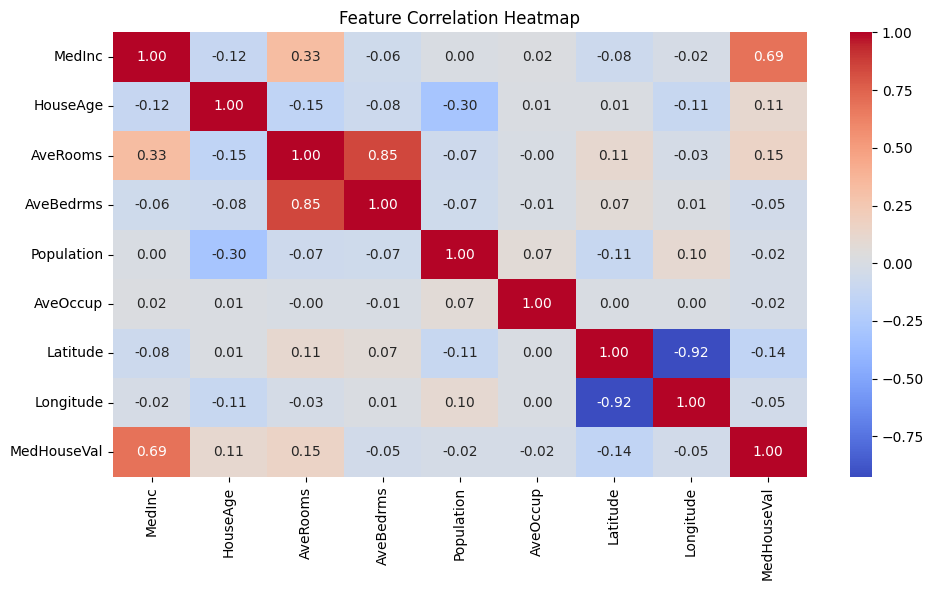

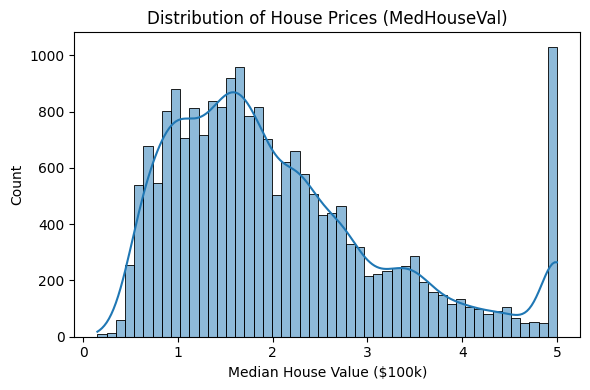


Training samples : 16512
Testing  samples : 4128

 Linear Regression
  RMSE : 0.7456
  MAE  : 0.5332
  R²   : 0.5758

 Random Forest
  RMSE : 0.5053
  MAE  : 0.3275
  R²   : 0.8051


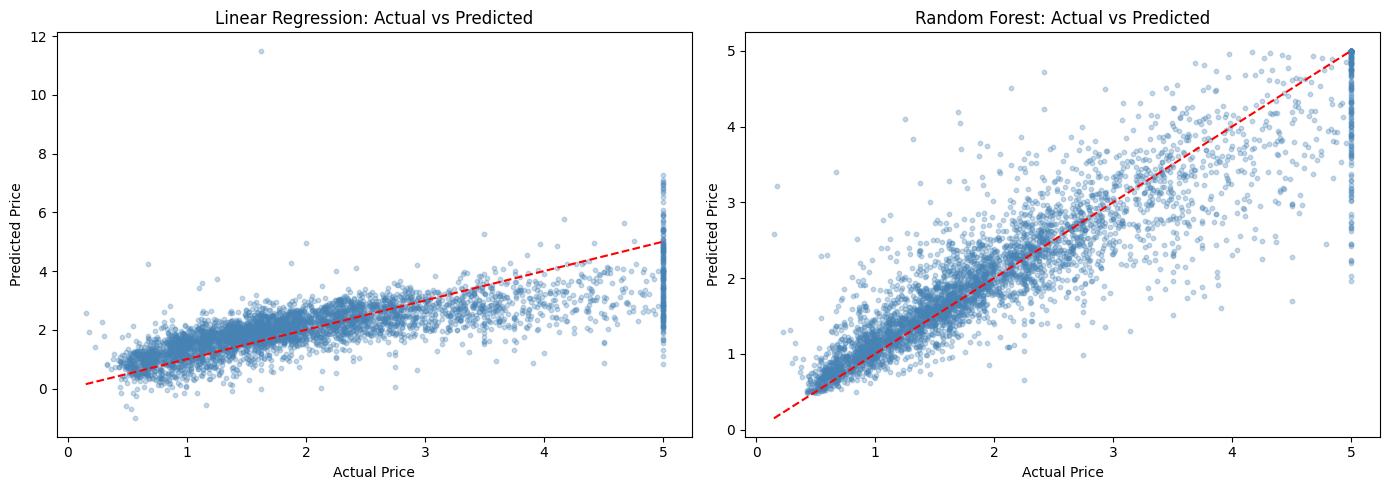

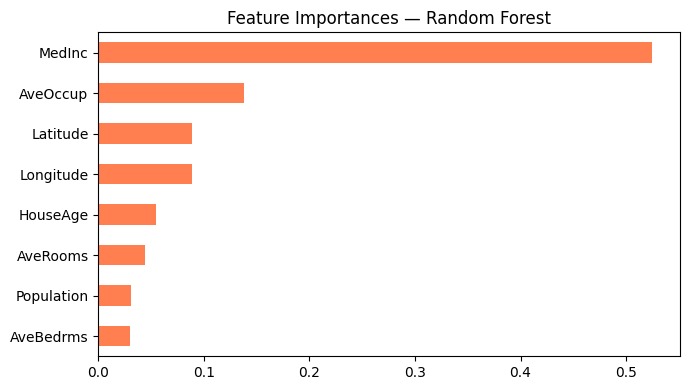

In [1]:
# ============================================================
# Task 1: House Price Prediction
# Dataset : California Housing (sklearn built-in)
# Models  : Linear Regression  |  Random Forest Regressor
# Metrics : RMSE, MAE, R²
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── 1. LOAD DATA ─────────────────────────────────────────────
data = fetch_california_housing(as_frame=True)
df = data.frame                          # Full DataFrame (features + target)
print("Shape:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum())

# ── 2. EXPLORATORY DATA ANALYSIS ─────────────────────────────
print("\nDescriptive stats:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

# Target distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["MedHouseVal"], bins=50, kde=True)
plt.title("Distribution of House Prices (MedHouseVal)")
plt.xlabel("Median House Value ($100k)")
plt.tight_layout()
plt.savefig("price_distribution.png", dpi=150)
plt.show()

# ── 3. PREPROCESSING ─────────────────────────────────────────
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# ── 4. MODEL TRAINING ─────────────────────────────────────────

# ---- Model 1: Linear Regression ----
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# ---- Model 2: Random Forest ----
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)          # RF doesn't need scaling
y_pred_rf = rf.predict(X_test)

# ── 5. EVALUATION ─────────────────────────────────────────────

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f" {name}")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2

evaluate("Linear Regression",   y_test, y_pred_lr)
evaluate("Random Forest",        y_test, y_pred_rf)

# ── 6. VISUALISATIONS ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [
    ("Linear Regression", y_pred_lr),
    ("Random Forest",     y_pred_rf)
]):
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", lw=1.5)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(f"{name}: Actual vs Predicted")

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

# Feature importance (Random Forest only)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(7, 4), color="coral")
plt.title("Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()